In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import kagglehub
import pandas as pd

# 1. Download the dataset folder using kagglehub
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
print("Path to downloaded folder:", path)

Using Colab cache for faster access to the 'ecommerce-customer-churn-analysis-and-prediction' dataset.
Path to downloaded folder: /kaggle/input/ecommerce-customer-churn-analysis-and-prediction


In [ ]:
# 2. List files inside the folder to verify
print("Files in folder:", os.listdir(path))

Files in folder: ['E Commerce Dataset.xlsx']


In [ ]:
# 3. Read the Excel file directly into a pandas DataFrame
# Note: This dataset uses an Excel format (.xlsx) and the sheet name is 'E Comm'
file_path = os.path.join(path, "E Commerce Dataset.xlsx")
df = pd.read_excel(file_path, sheet_name='E Comm')

In [ ]:
# 4. Verify the data loaded successfully
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5630, 20)
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionS

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Churn', 'CustomerID'])
y = df['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4504, 18)
X_test shape: (1126, 18)


In [ ]:
# Check how many missing values exist in each column of X_train
missing_values = X_train.isnull().sum()
print(missing_values[missing_values > 0])

Tenure                         213
WarehouseToHome                206
HourSpendOnApp                 197
OrderAmountHikeFromlastYear    208
CouponUsed                     208
OrderCount                     212
DaySinceLastOrder              247
dtype: int64


In [ ]:
# 1. Basic DataFrame info (non-null counts and data types)
print("--- DataFrame Info ---")
X_train.info()

print("\n" + "="*50 + "\n")

# 2. Detailed summary of missing values and data types
missing_df = pd.DataFrame({
    'Data Type': X_train.dtypes,
    'Missing Count': X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train)) * 100,
    'Unique Values': X_train.nunique()
})

# Sort by missing percentage descending to see problematic columns first
print(missing_df.sort_values(by='Missing Percentage (%)', ascending=False))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4504 entries, 1787 to 5140
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Tenure                       4291 non-null   float64
 1   PreferredLoginDevice         4504 non-null   object 
 2   CityTier                     4504 non-null   int64  
 3   WarehouseToHome              4298 non-null   float64
 4   PreferredPaymentMode         4504 non-null   object 
 5   Gender                       4504 non-null   object 
 6   HourSpendOnApp               4307 non-null   float64
 7   NumberOfDeviceRegistered     4504 non-null   int64  
 8   PreferedOrderCat             4504 non-null   object 
 9   SatisfactionScore            4504 non-null   int64  
 10  MaritalStatus                4504 non-null   object 
 11  NumberOfAddress              4504 non-null   int64  
 12  Complain                     4504 non-null   int64  
 1

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Numerical columns
num_cols = [
    'Tenure',
    'CityTier',
    'WarehouseToHome',
    'HourSpendOnApp',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'Complain',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
    'CashbackAmount'
]

# Categorical columns
cat_cols = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'PreferedOrderCat',
    'Gender',
    'MaritalStatus'
]

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Complete ML pipeline
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

# Train the complete pipeline
rf_pipeline.fit(X_train, y_train)

print("Random Forest pipeline trained successfully!")

Random Forest pipeline trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred_pipeline = rf_pipeline.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_pipeline)

print(f"Pipeline Random Forest Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pipeline))

Pipeline Random Forest Accuracy: 97.34%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       936
           1       1.00      0.84      0.91       190

    accuracy                           0.97      1126
   macro avg       0.98      0.92      0.95      1126
weighted avg       0.97      0.97      0.97      1126



feature-importance

Top 10 Predictive Features:
                             Feature  Importance
0                        num__Tenure    0.246679
12               num__CashbackAmount    0.095015
7                      num__Complain    0.061395
2               num__WarehouseToHome    0.060398
11            num__DaySinceLastOrder    0.057987
6               num__NumberOfAddress    0.050242
8   num__OrderAmountHikeFromlastYear    0.049147
5             num__SatisfactionScore    0.046156
4      num__NumberOfDeviceRegistered    0.030655
10                   num__OrderCount    0.030082


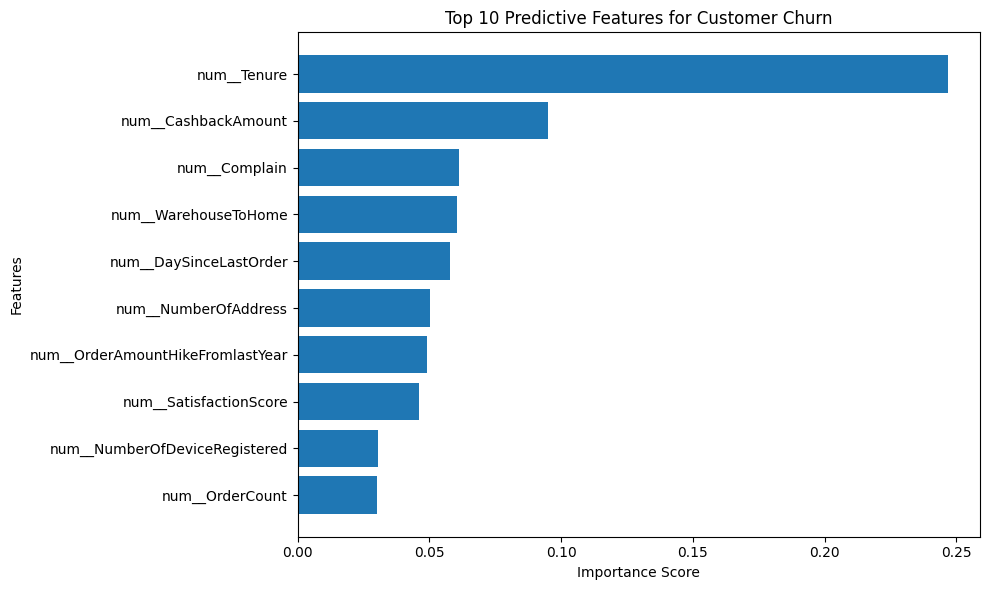

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance from Random Forest
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create and sort feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 10 features
top_features = feature_importance_df.head(10)

print("Top 10 Predictive Features:")
print(top_features)

# Visualization
plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Predictive Features for Customer Churn")
plt.tight_layout()
plt.show()

Replace your model-saving code

Your current notebook saves three separate files: churn_model.pkl, scaler.pkl, and imputer.pkl.

In [ ]:
import joblib

joblib.dump(
    rf_pipeline,
    'churn_pipeline.pkl'
)

print("Complete churn pipeline saved successfully!")

Complete churn pipeline saved successfully!


In [ ]:
import pandas as pd
import joblib

# Load the complete pipeline
rf_pipeline = joblib.load('churn_pipeline.pkl')

# Load new client data
new_client_data = pd.read_csv('/content/new_customers.csv')

# Keep CustomerID for the final report
customer_ids = new_client_data['CustomerID']

# Remove CustomerID before prediction
prediction_features = new_client_data.drop(
    columns=['CustomerID']
)

# Predict churn
predictions = rf_pipeline.predict(prediction_features)

# Get churn probabilities
probabilities = rf_pipeline.predict_proba(
    prediction_features
)[:, 1]

# Create prediction report
output_report = pd.DataFrame({
    'CustomerID': customer_ids,
    'Predicted_Churn': predictions,
    'Churn_Probability_%': (
        probabilities * 100
    ).round(2)
})

# Save report
output_report.to_csv(
    'client_churn_predictions_report.csv',
    index=False
)

print("Prediction report generated successfully!")
print(output_report.head(15))

Prediction report generated successfully!
    CustomerID  Predicted_Churn  Churn_Probability_%
0        55481                0                  3.0
1        55482                0                  0.0
2        55483                0                  1.0
3        55484                0                  0.0
4        55485                0                  1.0
5        55486                0                  3.0
6        55487                1                 98.0
7        55488                0                  1.0
8        55489                0                  7.0
9        55490                0                  2.0
10       55491                0                  6.0
11       55492                0                  1.0
12       55493                1                 95.0
13       55494                1                 83.0
14       55495                0                  6.0
